In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pydataset import data

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

In [18]:
chickwts = data("chickwts")

print(chickwts.head())
print(chickwts.info())

   weight       feed
1     179  horsebean
2     160  horsebean
3     136  horsebean
4     227  horsebean
5     217  horsebean
<class 'pandas.core.frame.DataFrame'>
Index: 71 entries, 1 to 71
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   weight  71 non-null     int64 
 1   feed    71 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.7+ KB
None


In [19]:
print(chickwts.isnull().sum())

weight    0
feed      0
dtype: int64


In [20]:
# Calculate Average Weight per Feed
feed_data = chickwts.groupby("feed")["weight"].mean().reset_index()

print(feed_data)

        feed      weight
0     casein  323.583333
1  horsebean  160.200000
2    linseed  218.750000
3   meatmeal  276.909091
4    soybean  246.428571
5  sunflower  328.916667


In [21]:
# standardize the weight
scaler = StandardScaler()

scaled_weight = scaler.fit_transform(feed_data[["weight"]])

In [22]:
# apply PCA
pca = PCA(n_components=1)

feed_pca = pca.fit_transform(scaled_weight)

feed_data["PC1"] = feed_pca

print(feed_data)

        feed      weight       PC1
0     casein  323.583333  1.091532
1  horsebean  160.200000 -1.675457
2    linseed  218.750000 -0.683880
3   meatmeal  276.909091  0.301077
4    soybean  246.428571 -0.215128
5  sunflower  328.916667  1.181855


In [23]:
# Compute Cosine Similarity

similarity_matrix = cosine_similarity(feed_data[["PC1"]])

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=feed_data["feed"],
    columns=feed_data["feed"]
)

print(similarity_df.round(3))

feed       casein  horsebean  linseed  meatmeal  soybean  sunflower
feed                                                               
casein        1.0       -1.0     -1.0       1.0     -1.0        1.0
horsebean    -1.0        1.0      1.0      -1.0      1.0       -1.0
linseed      -1.0        1.0      1.0      -1.0      1.0       -1.0
meatmeal      1.0       -1.0     -1.0       1.0     -1.0        1.0
soybean      -1.0        1.0      1.0      -1.0      1.0       -1.0
sunflower     1.0       -1.0     -1.0       1.0     -1.0        1.0


In [24]:
# recommendation function

def recommend_feed(feed_name, similarity_df, top_n=3):

    scores = similarity_df.loc[feed_name]

    recommendations = (
        scores
        .drop(feed_name)
        .sort_values(ascending=False)
        .head(top_n)
    )

    return recommendations

In [25]:
recommendations = recommend_feed("casein", similarity_df)

print(recommendations)

feed
meatmeal     1.0
sunflower    1.0
horsebean   -1.0
Name: casein, dtype: float64


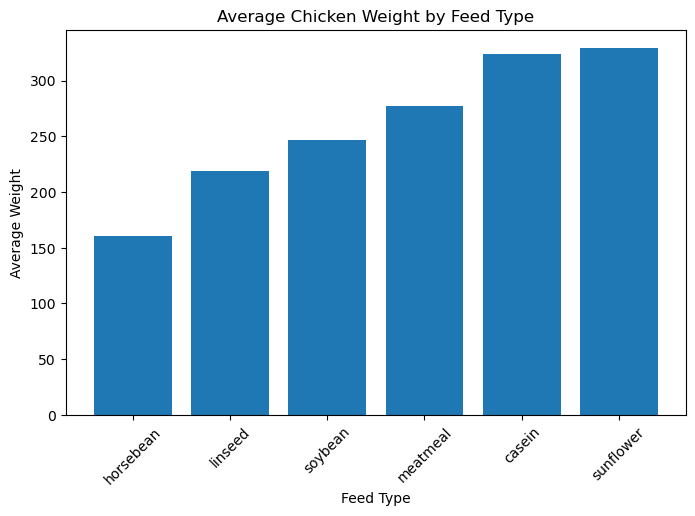

In [26]:
# Visualize Feed Performance

feed_data = feed_data.sort_values("weight")

plt.figure(figsize=(8,5))

plt.bar(feed_data["feed"], feed_data["weight"])

plt.title("Average Chicken Weight by Feed Type")

plt.xlabel("Feed Type")

plt.ylabel("Average Weight")

plt.xticks(rotation=45)

plt.savefig("../images/feed_weights.png", dpi=300, bbox_inches="tight")
plt.show()

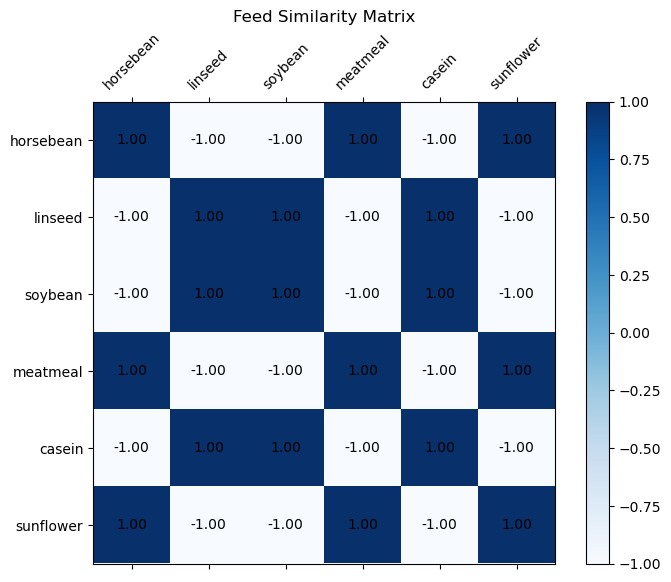

In [27]:
# Visualize Similarity Matrix
fig, ax = plt.subplots(figsize=(8,6))

cax = ax.matshow(similarity_df, cmap="Blues")

plt.colorbar(cax)

ax.set_xticks(range(len(feed_data)))
ax.set_yticks(range(len(feed_data)))

ax.set_xticklabels(feed_data["feed"], rotation=45)
ax.set_yticklabels(feed_data["feed"])

# Display similarity values
for i in range(len(feed_data)):
    for j in range(len(feed_data)):
        ax.text(
            j,
            i,
            f"{similarity_df.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.title("Feed Similarity Matrix")
plt.savefig("../images/feed_similarity.png", dpi=300, bbox_inches="tight")
plt.show()

## Analysis
The recommendation system identified meatmeal and sunflower as the most similar feed types to the selected feed based on standardized weight performance. Both received a cosine similarity score of 1.0, indicating highly similar performance characteristics. In contrast, horsebean received a similarity score of -1.0, suggesting that its performance differs substantially and it would not be recommended as a substitute.